In [1]:
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("ggplot")

pd.set_option("display.max_columns", None)

In [2]:
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

df = pd.read_csv(
    PROJECT_ROOT / "data" / "processed" / "launches.csv",
    parse_dates=["launch_time"]
)

df.head()

,id,name,provider,rocket,status,launch_time,pad,mission_type,year,month
0,e3df2ecd-c239-472f-95e4-2b89b4f75800,Sputnik 8K74PS | Sputnik 1,Soviet Space Program,Sputnik 8K74PS,Launch Successful,1957-10-04 19:28:34+00:00,1/5,Test Flight,1957,10
1,f8c9f344-a6df-4f30-873a-90fe3a7840b3,Sputnik 8K74PS | Sputnik 2,Soviet Space Program,Sputnik 8K74PS,Launch Successful,1957-11-03 02:30:00+00:00,1/5,Test Flight,1957,11
2,535c1a09-97c8-4f96-bb64-6336d4bcb1fb,Vanguard | Vanguard,US Navy,Vanguard,Launch Failure,1957-12-06 16:44:35+00:00,Launch Complex 18A,Test Flight,1957,12
3,1b9e28d0-c531-44b0-9b37-244e62a6d3f4,Juno-I | Explorer 1,Army Ballistic Missile Agency,Juno-I,Launch Successful,1958-02-01 03:47:56+00:00,Launch Complex 26A,Test Flight,1958,2
4,48bc7deb-b2e1-46c2-ab63-0ce00fbd192b,Vanguard | Vanguard,US Navy,Vanguard,Launch Failure,1958-02-05 07:33:00+00:00,Launch Complex 18A,Test Flight,1958,2


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype              
---  ------        --------------  -----              
 0   id            100 non-null    str                
 1   name          100 non-null    str                
 2   provider      100 non-null    str                
 3   rocket        100 non-null    str                
 4   status        100 non-null    str                
 5   launch_time   100 non-null    datetime64[us, UTC]
 6   pad           100 non-null    str                
 7   mission_type  100 non-null    str                
 8   year          100 non-null    int64              
 9   month         100 non-null    int64              
dtypes: datetime64[us, UTC](1), int64(2), str(7)
memory usage: 7.9 KB


In [4]:
df.describe(include="all")


,id,name,provider,rocket,status,launch_time,pad,mission_type,year,month
count,100,100,100,100,100,100,100,100,100.000000,100.000000
unique,100,92,6,25,3,NaN,16,9,NaN,NaN
top,e3df2ecd-c239-472f-95e4-2b89b4f75800,Vanguard | Vanguard,United States Air Force,Thor Agena A,Launch Failure,NaN,1/5,Government/Top Secret,NaN,NaN
freq,1,9,36,15,52,NaN,19,27,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,1959-08-25 20:48:25.360000+00:00,NaN,NaN,1959.070000,7.470000
min,NaN,NaN,NaN,NaN,NaN,1957-10-04 19:28:34+00:00,NaN,NaN,1957.000000,1.000000
25%,NaN,NaN,NaN,NaN,NaN,1958-10-11 18:27:01.750000+00:00,NaN,NaN,1958.000000,5.000000
50%,NaN,NaN,NaN,NaN,NaN,1959-09-17 21:57:03.500000+00:00,NaN,NaN,1959.000000,8.000000
75%,NaN,NaN,NaN,NaN,NaN,1960-07-07 00:53:18+00:00,NaN,NaN,1960.000000,10.000000
max,NaN,NaN,NaN,NaN,NaN,1960-12-07 20:20:58+00:00,NaN,NaN,1960.000000,12.000000


In [5]:
df.isnull().sum()

id              0
name            0
provider        0
rocket          0
status          0
launch_time     0
pad             0
mission_type    0
year            0
month           0
dtype: int64

In [6]:
provider_counts = df["provider"].value_counts()

provider_counts

provider
United States Air Force                          36
Soviet Space Program                             19
National Aeronautics and Space Administration    18
US Navy                                          17
Army Ballistic Missile Agency                     9
US Army                                           1
Name: count, dtype: int64

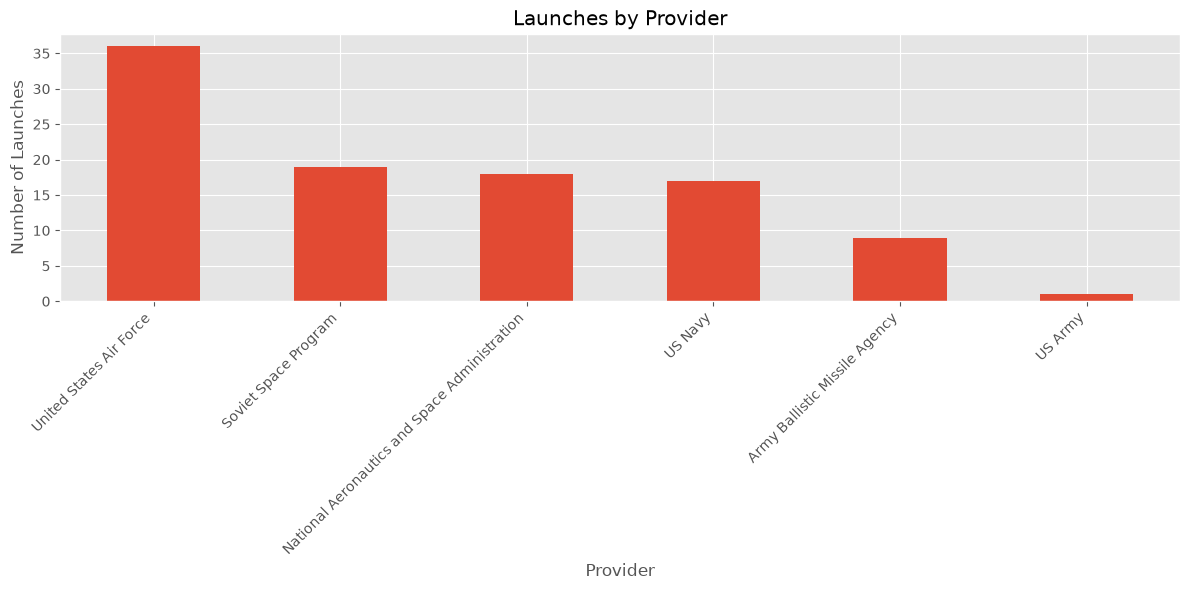

In [7]:
provider_counts.plot(
    kind="bar",
    figsize=(12,6)
)

plt.title("Launches by Provider")
plt.xlabel("Provider")
plt.ylabel("Number of Launches")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

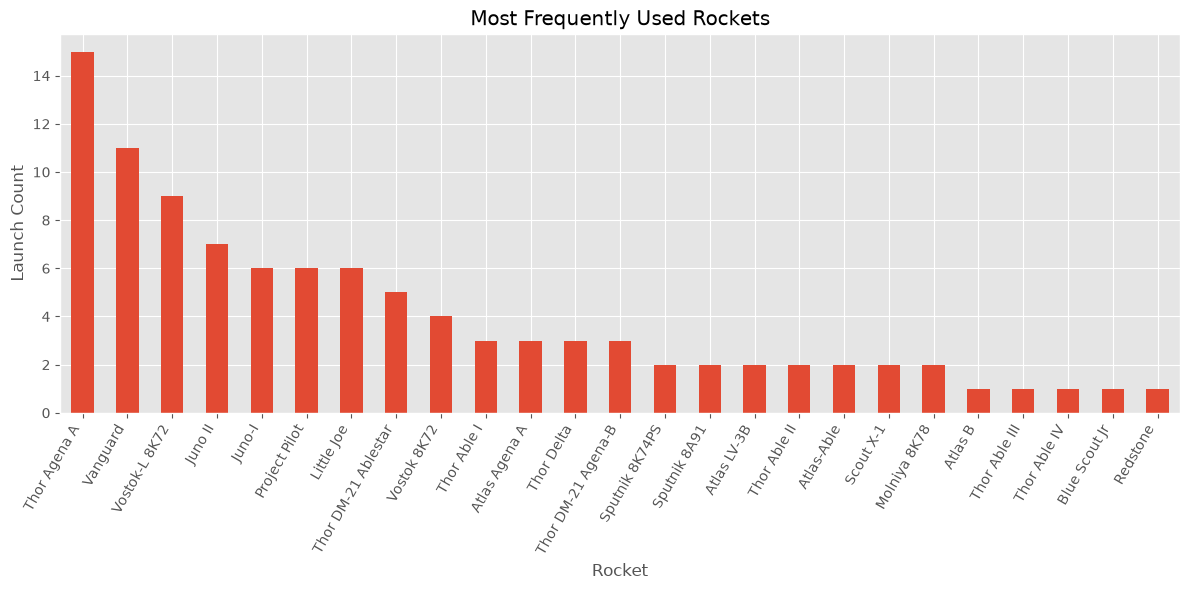

In [8]:
rocket_counts = df["rocket"].value_counts()

rocket_counts.plot(
    kind="bar",
    figsize=(12,6)
)

plt.title("Most Frequently Used Rockets")
plt.xlabel("Rocket")
plt.ylabel("Launch Count")

plt.xticks(rotation=60, ha="right")

plt.tight_layout()
plt.show()

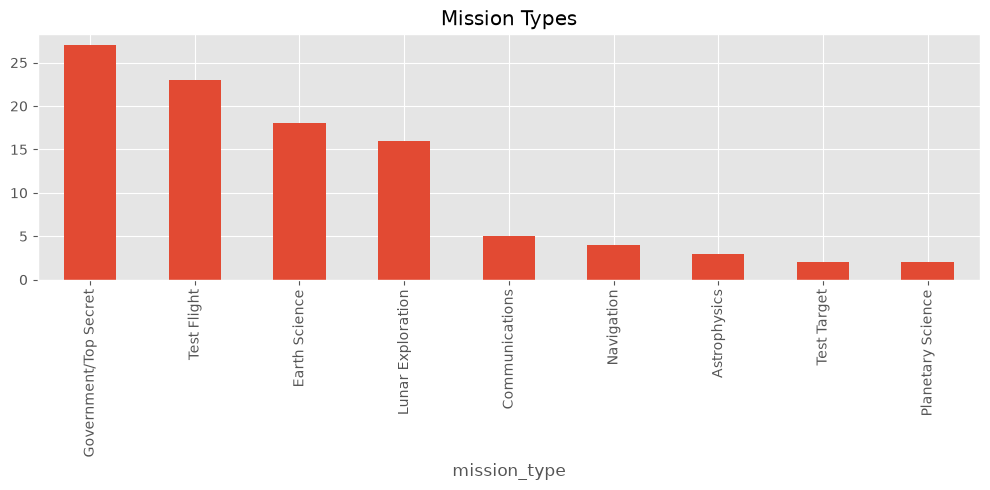

In [9]:
mission_counts = df["mission_type"].value_counts()

mission_counts.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Mission Types")

plt.tight_layout()

plt.show()

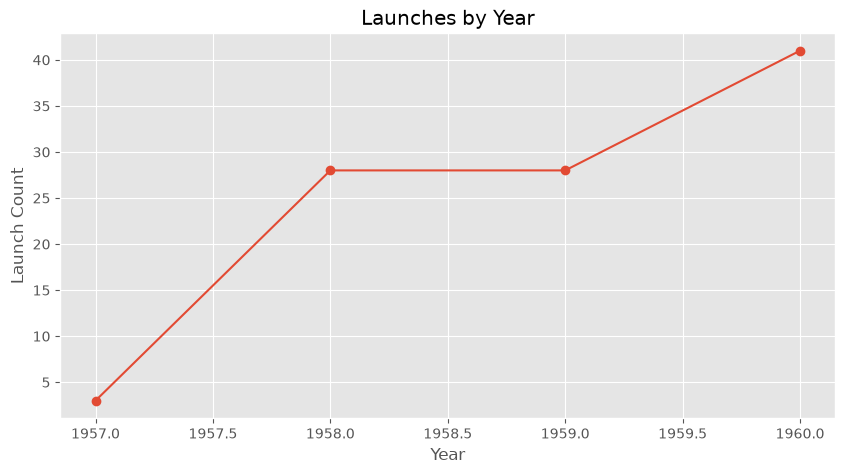

In [10]:
year_counts = df["year"].value_counts().sort_index()

year_counts.plot(
    marker="o",
    figsize=(10,5)
)

plt.title("Launches by Year")

plt.xlabel("Year")

plt.ylabel("Launch Count")

plt.grid(True)

plt.show()